# TikTok Content Moderation and Engagement Analysis

Author: David Zhang  

## 1. Project Background

TikTok is a short-form video platform where user engagement plays a critical role in content distribution. 

Understanding what factors influence engagement helps improve recommendation systems and content moderation strategies.

This project investigates:

1. How are engagement metrics distributed across videos on the platform?
2. Do creator moderation signals (e.g., author ban status) relate to engagement outcomes?
3. Does claim-based content generate more discussion and sharing than opinion-based content?
4. What textual characteristics are associated with viral videos?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Dataset Overview

The dataset contains information about TikTok videos including:

- Video metadata
- Creator status
- Engagement metrics

In [2]:
df = pd.read_csv("tiktok_dataset.csv")
df.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


In [3]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


#                             0
claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

## 3. data cleaning

Before further analysis, we check the dataset, found that the dataset contains minimal missing values and does not require major cleaning.

In [4]:
required_numeric = [
    'video_view_count',
    'video_like_count',
    'video_comment_count',
    'video_share_count',
    'video_duration_sec'
]

df = df.dropna(subset=required_numeric).reset_index(drop=True)
df['video_transcription_text'] = df['video_transcription_text'].fillna("")
df['verified_status'] = df['verified_status'].fillna("unknown")
df['author_ban_status'] = df['author_ban_status'].fillna("unknown")
df['claim_status'] = df['claim_status'].fillna("unknown")

In [5]:
df.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19084.000000,1.908400e+04,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9542.500000,5.624840e+09,32.423811,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5509.220604,2.537030e+09,16.226470,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4771.750000,3.425100e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9542.500000,5.609500e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14313.250000,7.840823e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19084.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


## 4. Engagement Overview

Before examining specific factors that may influence engagement, we first explore the overall distribution of engagement rates across videos.

In [6]:
df = df[df["video_view_count"] > 0].copy()
df["engagement_rate"] = (df["video_like_count"] + df["video_comment_count"] + df["video_share_count"]) / df["video_view_count"]
df["share_rate"] = df["video_share_count"] / df["video_view_count"]
df["comment_rate"] = df["video_comment_count"] / df["video_view_count"]
df["download_rate"] = df["video_download_count"] / df["video_view_count"]
df["discussion_rate"] = df["video_comment_count"] / (df["video_like_count"] + 1)

### Engagement Rate Distribution

We visualize the distribution of engagement rates to understand general interaction patterns.

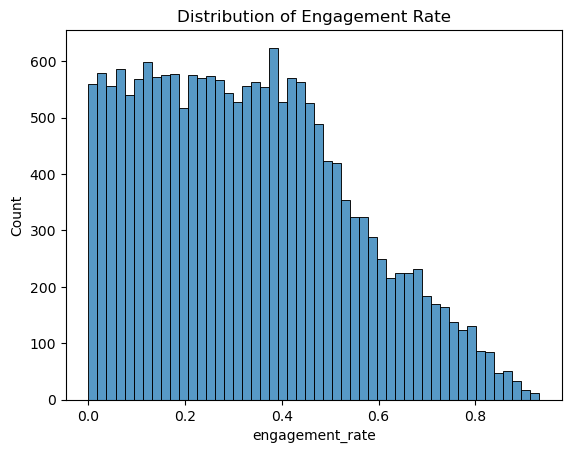

In [7]:
sns.histplot(df["engagement_rate"], bins=50)
plt.title("Distribution of Engagement Rate")
plt.show()

Most videos have engagement rates between 0.1 and 0.5, suggesting moderate interaction levels. A small portion of videos achieve extremely high engagement.

## 5. Author Factors and Engagement

Next, we examine whether creator-related moderation signals, such as author ban status, are associated with differences in engagement metrics.

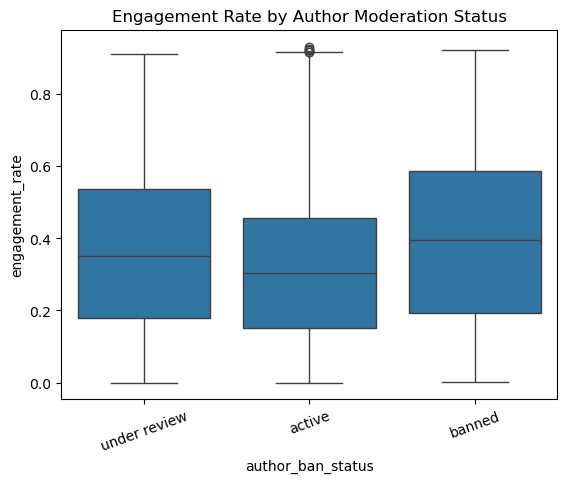

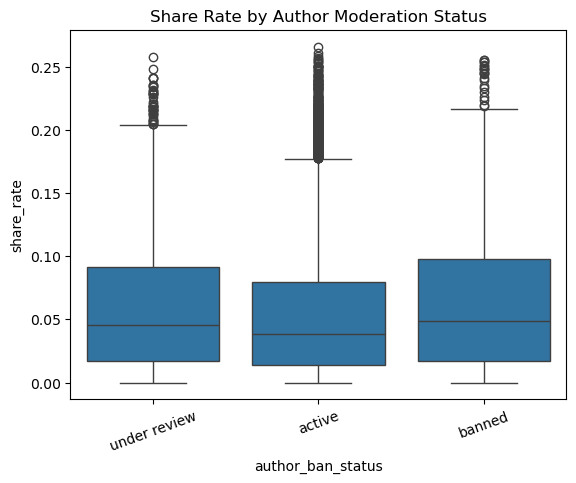

In [8]:
sns.boxplot(x="author_ban_status", y="engagement_rate", data=df)
plt.xticks(rotation=20)
plt.title("Engagement Rate by Author Moderation Status")
plt.show()

sns.boxplot(x="author_ban_status", y="share_rate", data=df)
plt.xticks(rotation=20)
plt.title("Share Rate by Author Moderation Status")
plt.show()

### Insights:

**1. Algorithmic Amplification of Risky Accounts (Engagement Rate):**
The first boxplot reveals that accounts under banned and under review statuses exhibit a significantly wider variance in overall engagement rates. This suggests a critical business challenge: violating accounts often rely on highly controversial or sensational content to manipulate the recommendation algorithm and harvest massive abnormal traffic before the platform intervenes.

**2. Share Rate as a Leading Indicator of Risk:**
In contrast, the share rate exhibits many extreme values, indicating that a small subset of videos receives disproportionately high levels of sharing, which is consistent with the viral dynamics commonly observed on social media platforms.

## 6. Content Type and User Interaction

We then analyze whether claim-based videos generate more discussion and sharing compared to opinion-based videos.

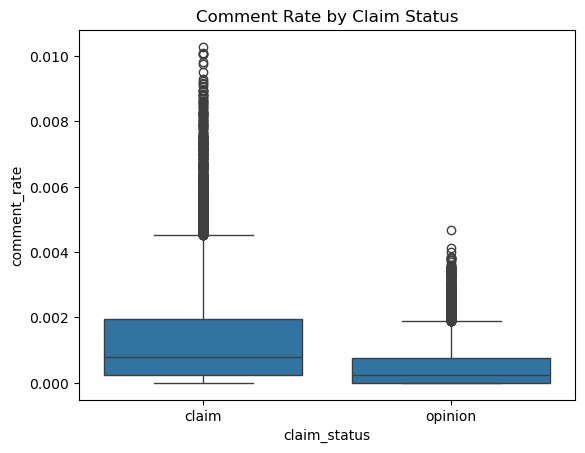

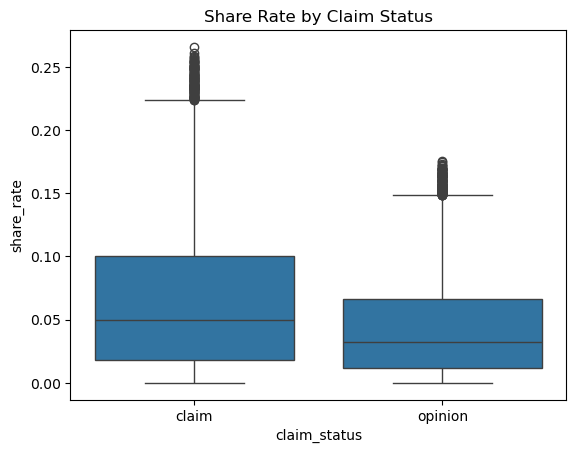

In [9]:
sns.boxplot(x="claim_status", y="comment_rate", data=df)
plt.title("Comment Rate by Claim Status")
plt.show()

sns.boxplot(x="claim_status", y="share_rate", data=df)
plt.title("Share Rate by Claim Status")
plt.show()

### Insights: Engagement Semantics & Discussion Intensity

**1.Claims Drive More Discussion:**

Videos labeled as claims show significantly higher comment rates compared to opinion-based videos. The distribution also contains more extreme outliers, indicating that claim-based content often triggers intense discussion.

This pattern suggests that factual or quasi-factual statements tend to provoke debate, fact-checking behavior, and disagreement among viewers, resulting in denser comment sections.

**2. Opinion Content Encourages Passive Engagement:**

Opinion-based videos generally exhibit lower comment rates and fewer extreme values. This indicates that opinions are more likely to be passively consumed or liked by audiences who already agree with the viewpoint.

In contrast, claims invite verification or dispute, creating stronger conversational engagement.

**Validation:**

To better comfirm the reliability of our insight, we need to perform a t-test.

In [10]:
from scipy.stats import ttest_ind

claim_comments = df[df["claim_status"] == "claim"]["comment_rate"]
opinion_comments = df[df["claim_status"] == "opinion"]["comment_rate"]
t_stat, p_value = ttest_ind(claim_comments, opinion_comments, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 48.210303990455465
P-value: 0.0


### Result Interpretation

The t-test produces a very large test statistic (t ≈ 48.21) and an extremely small p-value (p < 0.001), indicating that the difference in comment rates between claim-based and opinion-based videos is statistically significant.

This suggests that claim-based content tends to trigger substantially more discussion among viewers compared to opinion-based content and supports the earlier visual analysis, where claim-based videos exhibited higher median comment rates and more extreme discussion outliers.

## 7. Textual Characteristics of Viral Content

In [11]:
import seaborn as sns
from textblob import TextBlob

def get_sentiment(text):
    blob = TextBlob(str(text))
    # polarity: -1 to 1
    # subjectivity: 0 to 1
    return blob.sentiment.polarity, blob.sentiment.subjectivity

df[['polarity', 'subjectivity']] = pd.DataFrame(
    df['video_transcription_text'].apply(get_sentiment).tolist(), index=df.index
)
print(df[['video_transcription_text', 'polarity', 'subjectivity']].head())

                            video_transcription_text  polarity  subjectivity
0  someone shared with me that drone deliveries a...     -0.30          0.50
1  someone shared with me that there are more mic...      0.50          0.50
2  someone shared with me that american industria...      0.15          0.05
3  someone shared with me that the metro of st. p...     -0.15          0.40
4  someone shared with me that the number of busi...      0.00          0.00


C:\Users\david\AppData\Local\Temp\ipykernel_266944\1023810798.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='subjectivity_bin', y='share_rate', data=df, palette='Blues_d', capsize=0.1, errorbar=('ci', 95))
C:\Users\david\AppData\Local\Temp\ipykernel_266944\1023810798.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='polarity_bin', y='comment_rate', data=df, palette='coolwarm', showfliers=False)


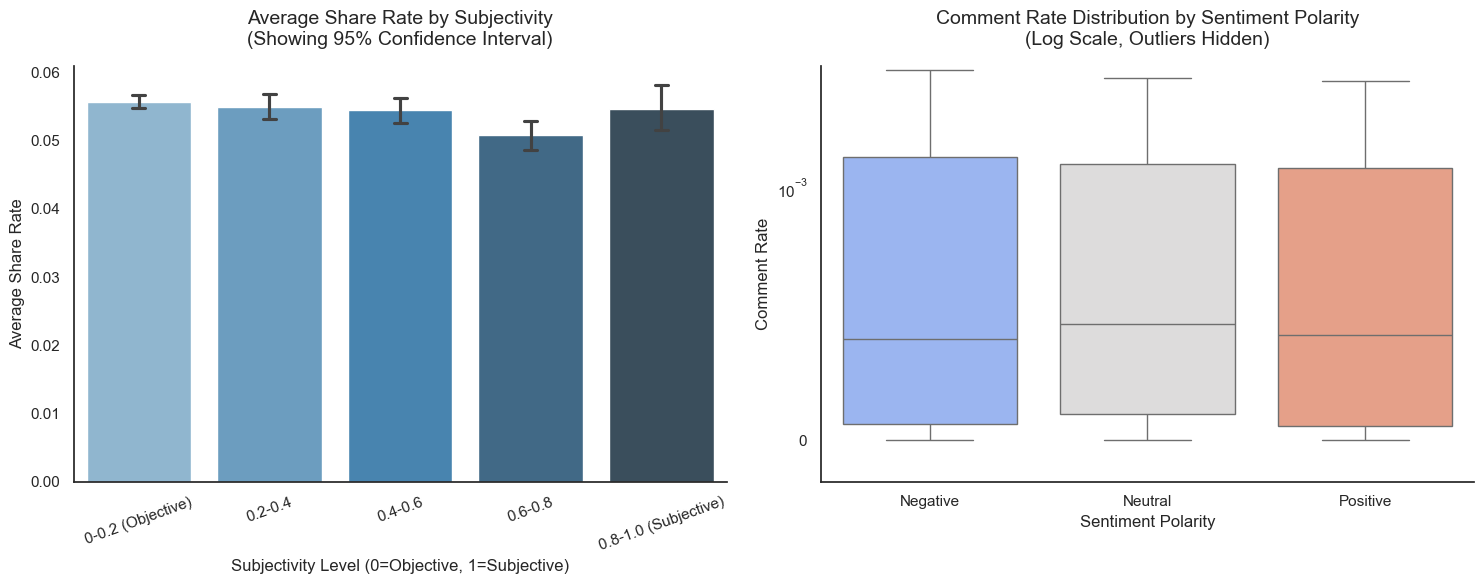

In [12]:

df['subjectivity_bin'] = pd.cut(df['subjectivity'], bins=5, 
                                labels=['0-0.2 (Objective)', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0 (Subjective)'])

df['polarity_bin'] = pd.cut(df['polarity'], bins=[-1, -0.3, 0.3, 1], 
                            labels=['Negative', 'Neutral', 'Positive'])

sns.set_theme(style="white", context="notebook")
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.barplot(x='subjectivity_bin', y='share_rate', data=df, palette='Blues_d', capsize=0.1, errorbar=('ci', 95))
plt.title('Average Share Rate by Subjectivity\n(Showing 95% Confidence Interval)', fontsize=14, pad=15)
plt.xlabel('Subjectivity Level (0=Objective, 1=Subjective)', fontsize=12)
plt.ylabel('Average Share Rate', fontsize=12)
plt.xticks(rotation=20)
sns.despine() 

plt.subplot(1, 2, 2)
sns.boxplot(x='polarity_bin', y='comment_rate', data=df, palette='coolwarm', showfliers=False) 
plt.yscale('symlog', linthresh=0.001)
plt.title('Comment Rate Distribution by Sentiment Polarity\n(Log Scale, Outliers Hidden)', fontsize=14, pad=15)
plt.xlabel('Sentiment Polarity', fontsize=12)
plt.ylabel('Comment Rate', fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

### Insights: The Nuance of Textual Features

**1. The Stability of Share Rates Across Subjectivity :**
From the barplot with confidence intervals, we observe that the average `share_rate` remains stable (around 5.0% to 5.5%) across almost all levels of content subjectivity， which shows both objective claims and highly subjective personal stories have equal baseline potential to be shared. 

**2. The Consistency of Comment Rates Across Sentiments:**
The distribution of `comment_rate` across the three sentiment categories appears broadly similar. While there is some variation in spread, the overall medians are relatively close. This suggests that sentiment polarity alone does not strongly determine how much discussion a video generates.

Although negative or emotionally charged content is often expected to trigger stronger reactions, the results indicate that discussion intensity on the platform may be influenced more by content semantics—such as claims, controversial topics, or factual statements—rather than simple emotional polarity.

**TF-IDF viral words**

C:\Users\david\AppData\Local\Temp\ipykernel_266944\873322498.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_viral_words, x="score", y="word", palette="Reds_r")
C:\Users\david\AppData\Local\Temp\ipykernel_266944\873322498.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_nonviral_words, x="score", y="word", palette="Blues_r")


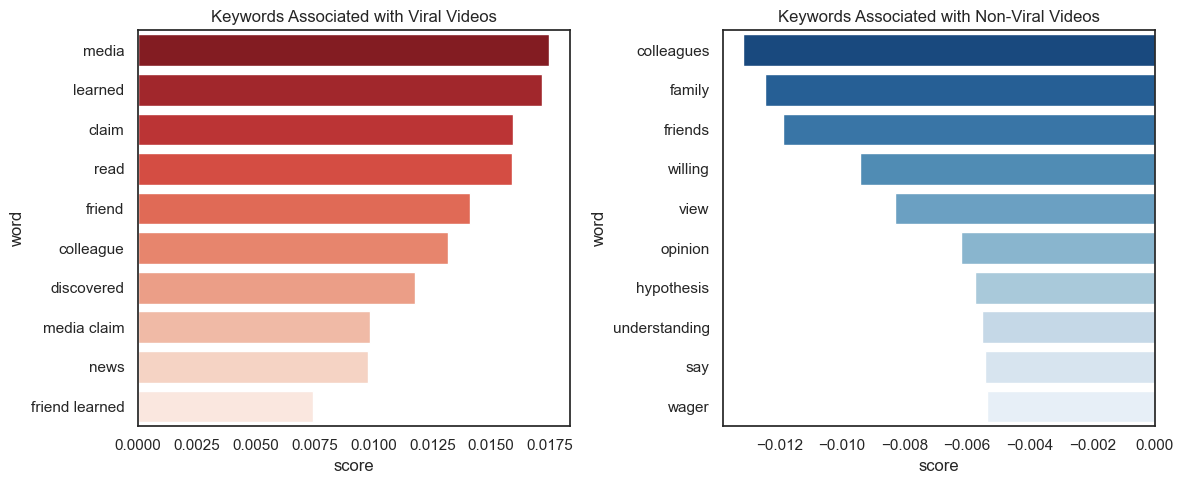

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
threshold = df["share_rate"].quantile(0.90)
df["is_viral"] = (df["share_rate"] >= threshold).astype(int)
tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    max_features=2000,
    min_df= 10,
    max_df = 0.8
)

X = tfidf.fit_transform(df["video_transcription_text"].fillna(""))
vocab = np.array(tfidf.get_feature_names_out())
viral_mask = df["is_viral"] == 1
nonviral_mask = df["is_viral"] == 0
avg_viral = np.asarray(X[viral_mask].mean(axis=0)).ravel()
avg_nonviral = np.asarray(X[nonviral_mask].mean(axis=0)).ravel()
diff = avg_viral - avg_nonviral

top_viral_words = pd.DataFrame({
    "word": vocab,
    "score": diff
}).sort_values("score", ascending=False).head(10)

top_nonviral_words = pd.DataFrame({
    "word": vocab,
    "score": diff
}).sort_values("score").head(10)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.barplot(data=top_viral_words, x="score", y="word", palette="Reds_r")
plt.title("Keywords Associated with Viral Videos")
plt.subplot(1,2,2)
sns.barplot(data=top_nonviral_words, x="score", y="word", palette="Blues_r")
plt.title("Keywords Associated with Non-Viral Videos")
plt.tight_layout()
plt.show()

### Interpretation of Viral vs Non-Viral Keywords

The TF-IDF comparison highlights words that appear more frequently in the top 10% of videos by share rate (defined as viral). These keywords suggest that viral content often contains more opinionated, emotional, or engaging language that may encourage audience interaction and sharing.

This pattern indicates that the style and framing of content may influence how widely a video is shared. However, these keywords represent associations rather than causal relationships, and they should be interpreted as linguistic patterns commonly observed in highly shared videos.

## 8. Predictive Signals of Virality
We train a Random Forest model to identify which features are most predictive of viral videos.

C:\Users\david\AppData\Local\Temp\ipykernel_266944\2228517204.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')


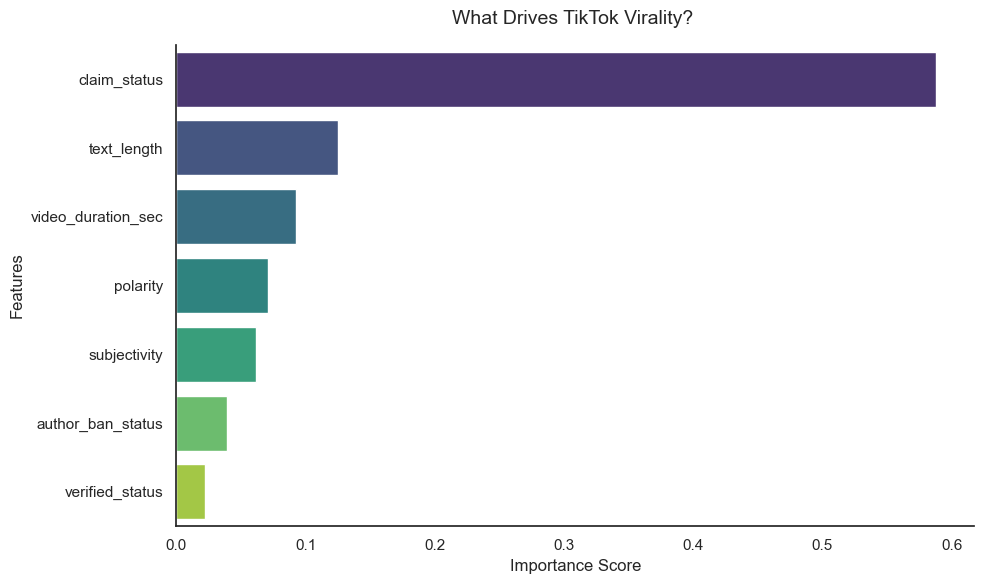

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

X = pd.DataFrame()
X['video_duration_sec'] = df['video_duration_sec']
X['subjectivity'] = df['subjectivity']
X['polarity'] = df['polarity']
X['text_length'] = df['video_transcription_text'].astype(str).apply(len)
le = LabelEncoder()
X['verified_status'] = le.fit_transform(df['verified_status']) 
X['author_ban_status'] = le.fit_transform(df['author_ban_status'])
X['claim_status'] = le.fit_transform(df['claim_status'].astype(str))
y = df['is_viral']

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', max_depth=7)
rf.fit(X, y)
fi_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
plt.title('What Drives TikTok Virality? ', fontsize=14, pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

To better understand what factors contribute to viral videos, we trained a Random Forest classifier to predict whether a video belongs to the top of share rates.

The feature importance analysis suggest that claaim-based content is the strongest predictor of virality. Videos presenting factual claims or information appear significantly more likely to be shared compared to opinion-based content.

Additionally, longer transcripts and longer video durations are associated with hiher virality, suggesting that content with more narrative depth or informational value may encourage audience engagement and sharing behavior.

Sentiment features also contribute to virality prediction, indicating that emotional tone may influence how audiences interact with content.

## 9. Estimating the Effect of Claim-Based Content

Previous analyses show that claim videos appear to generate more sharing behavior. However, this relationship may be influenced by other content characteristics.

To further investigate this relationship, we use propensity score matching (PSM) to estimate the effect of claim-based content on share rates while controlling for observable covariates.

Base ATT: 0.02287 | Matched treated: 9608

=== Bootstrapped PSM Results ===
Valid bootstraps: 1000/1000
Avg matched treated per draw: 9610.5
ATT point estimate: 0.02287
95% CI: [0.02107, 0.02521]
Significant (CI excludes 0): YES


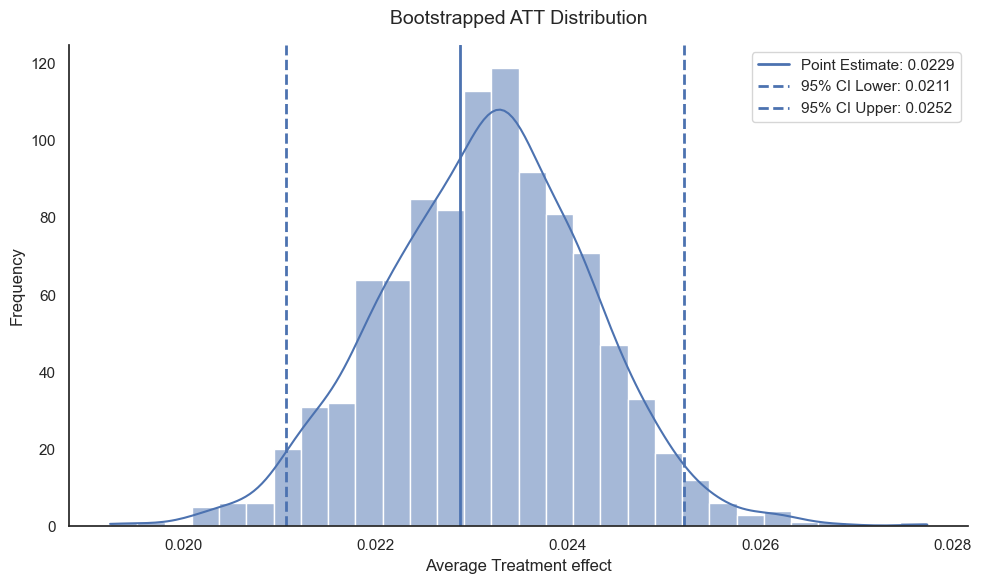

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
df['text_length'] = df['video_transcription_text'].astype(str).apply(len)
needed = ['claim_status','verified_status','author_ban_status',
          'video_duration_sec','subjectivity','polarity','text_length','share_rate']
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

df_model = df[needed].copy()
# enforce types
df_model['treatment'] = (df_model['claim_status'] == 'claim').astype(int)
for c in ['video_duration_sec','subjectivity','polarity','text_length','share_rate']:
    df_model[c] = pd.to_numeric(df_model[c], errors='coerce')

df_model = df_model.dropna().reset_index(drop=True)
# covariates
features_to_control = ['video_duration_sec', 'subjectivity', 'polarity', 'text_length']
X_covariates = pd.get_dummies(
    df_model[features_to_control + ['verified_status', 'author_ban_status']],
    drop_first=True
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_covariates)

n = len(df_model)
rng = np.random.default_rng(42)

def matching_getATT(data_indices, caliper_multiplier=0.2):
    sample_df = df_model.iloc[data_indices].copy()
    sample_X = X_scaled[data_indices]
    if sample_df['treatment'].nunique() < 2:
        return np.nan, 0

    lr = LogisticRegression(random_state=42, max_iter=2000)
    lr.fit(sample_X, sample_df['treatment'])
    sample_df['propensity_score'] = lr.predict_proba(sample_X)[:, 1]
    treated = sample_df[sample_df['treatment'] == 1].copy().reset_index(drop=True)
    control = sample_df[sample_df['treatment'] == 0].copy().reset_index(drop=True)

    if len(treated) == 0 or len(control) == 0:
        return np.nan, 0

    ps_std =sample_df['propensity_score'].std()
    caliper = caliper_multiplier * ps_std
    caliper = max(caliper, 1e-6) 

    nn = NearestNeighbors(n_neighbors=1, algorithm='auto')
    nn.fit(control[['propensity_score']])

    distances, indices = nn.kneighbors(treated[['propensity_score']])
    distances = distances.flatten()
    indices = indices.flatten()
    valid= distances <= caliper
    if valid.sum() == 0:
        return np.nan, 0
    
    matched_treated = treated.loc[valid].reset_index(drop=True)
    matched_control = control.iloc[indices[valid]].reset_index(drop=True)

    att = matched_treated['share_rate'].mean() - matched_control['share_rate'].mean()
    return att, len(matched_treated)

# point estimate
base_att, base_matched = matching_getATT(np.arange(n))
print(f"Base ATT: {base_att:.5f} | Matched treated: {base_matched}")

n_bootstraps = 1000
boot_atts = []
boot_matched_counts = []
for _ in range(n_bootstraps):
    boot_indice= rng.integers(0, n, size=n)
    att, matched_cnt = matching_getATT(boot_indice)
    if not np.isnan(att):
        boot_atts.append(att)
        boot_matched_counts.append(matched_cnt)

boot_atts = np.array(boot_atts)

if len(boot_atts) < 50:
    raise RuntimeError("Too few valid bootstrap sample")

lower = np.percentile(boot_atts, 2.5)
upper = np.percentile(boot_atts, 97.5)
sig = "YES" if (lower > 0) or (upper < 0) else "NO"

print("\n=== Bootstrapped PSM Results ===")
print(f"Valid bootstraps: {len(boot_atts)}/{n_bootstraps}")
print(f"Avg matched treated per draw: {np.mean(boot_matched_counts):.1f}")
print(f"ATT point estimate: {base_att:.5f}")
print(f"95% CI: [{lower:.5f}, {upper:.5f}]")
print(f"Significant (CI excludes 0): {sig}")

plt.figure(figsize=(10, 6))
sns.histplot(boot_atts, bins=30, kde=True)
plt.axvline(base_att, linestyle='-', linewidth=2, label=f'Point Estimate: {base_att:.4f}')
plt.axvline(lower, linestyle='--', linewidth=2, label=f'95% CI Lower: {lower:.4f}')
plt.axvline(upper, linestyle='--', linewidth=2, label=f'95% CI Upper: {upper:.4f}')
plt.title('Bootstrapped ATT Distribution', fontsize=14, pad=15)
plt.xlabel('Average Treatment effect')
plt.ylabel('Frequency')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

### Insight

The results suggest that claim-oriented content can act as a catalyst for user interaction. Such content may trigger stronger cognitive responses, including disagreement, verification behavior, or debate, which can increase the likelihood that users share the content.

From a platform perspective, this highlights a potential trade-off: while claim-based content can drive engagement and sharing, it may also require stronger moderation safeguards to ensure information quality and prevent the spread of misinformation.

## 10. Final Conclusion

This analysis explored how content characteristics, moderation signals, and textual features relate to engagement and sharing behavior on TikTok.

The results suggest that **claim-oriented content tends to generate more discussion and sharing**, indicating that controversial or opinion-driven topics may stimulate stronger user interaction. Text analysis also shows that certain linguistic patterns are more common among highly shared videos, highlighting the role of content framing in virality.

Machine learning and propensity score matching further support the idea that content style and structure may influence engagement outcomes. While these findings reveal meaningful associations, they do not establish direct causality due to the observational nature of the dataset.

Overall, the results provide insight into how **content framing, language, and topic structure may contribute to viral engagement patterns on short-form video platforms.**